In [1]:
import os
import pandas as pd
import collections
import plotly.express as px
import plotly.graph_objects as go

In [2]:
DATASET = "accel"

In [3]:
model_names = sorted(x[:-4].lstrip(DATASET + "_") for x in os.listdir("results/") if DATASET + "_" in x and x[-4:] == ".txt")

results = collections.defaultdict(list)

for model_name in model_names:
    with open(f"results/{DATASET}_{model_name}.txt", "r") as f:
        result = eval(f.read())

        results["Model"].append(model_name)
        
        results["Training Energy (J)"].append(result["Training"]["Energy (J)"])
        results["Training Time (s)"].append(result["Training"]["Time (s)"])
        
        results["RMSE (train)"].append(result["Calling (train)"]["RMSE"])
        results["RMSE (test)"].append(result["Calling (test)"]["RMSE"])
        results["RMSE (sample)"].append(result["Calling (sample)"]["RMSE"])
        
        results["PearsonR (train)"].append(result["Calling (train)"]["PearsonR"])
        results["PearsonR (test)"].append(result["Calling (test)"]["PearsonR"])
        results["PearsonR (sample)"].append(result["Calling (sample)"]["PearsonR"])
        
        results["Calling Time (train) (s)"].append(result["Calling (train)"]["Time (s)"])
        results["Calling Time (test) (s)"].append(result["Calling (test)"]["Time (s)"])
        results["Calling Time (sample) (s)"].append(result["Calling (sample)"]["Time (s)"])
        
        results["Calling Energy (train) (J)"].append(result["Calling (train)"]["Energy (J)"])
        results["Calling Energy (test) (J)"].append(result["Calling (test)"]["Energy (J)"])
        results["Calling Energy (sample) (J)"].append(result["Calling (sample)"]["Energy (J)"])

df = pd.DataFrame(results)
df

,Model,Training Energy (J),Training Time (s),RMSE (train),RMSE (test),RMSE (sample),PearsonR (train),PearsonR (test),PearsonR (sample),Calling Time (train) (s),Calling Time (test) (s),Calling Time (sample) (s),Calling Energy (train) (J),Calling Energy (test) (J),Calling Energy (sample) (J)
0,01linear,20.63,0.025454,24.4881,24.5168,23.7387,0.007,0.021,0.001,0.012125,0.009330,0.008581,19.60,18.14,17.05
1,01linearridgecv,20.62,0.049136,24.4881,24.5168,23.7387,0.007,0.021,0.001,0.012033,0.009339,0.008615,18.65,18.14,17.94
2,02gradboost,93.73,5.964202,11.1580,11.2216,10.8333,0.890,0.889,0.890,0.179510,0.050947,0.010095,21.18,18.95,17.46
3,02histgradboost,26.77,0.369779,9.9192,10.1274,9.7216,0.914,0.911,0.912,0.150101,0.047224,0.013912,23.08,19.91,17.79
4,03decisiontree,22.18,0.370484,4.3616,13.2585,7.5909,0.984,0.853,0.949,0.045833,0.018532,0.009246,19.38,18.48,17.20
5,04randomforest,322.87,23.222159,5.3870,10.6975,6.9940,0.976,0.901,0.956,2.964755,0.798358,0.059122,60.20,35.77,26.41
6,04randomforest2,53.00,2.692230,17.7833,17.8040,17.2486,0.688,0.688,0.687,0.147504,0.048959,0.016567,20.93,19.10,17.78
7,05kneighbours,19.00,0.090623,8.4819,10.5388,8.7961,0.938,0.904,0.930,0.969512,0.269487,0.017938,31.09,21.75,17.40
8,06bagging,50.29,2.344750,5.7704,11.0147,7.3364,0.972,0.895,0.951,0.321504,0.090926,0.014850,24.40,20.29,18.81
9,07mlp_sgd,273.79,20.321766,10.9842,11.0424,10.7115,0.894,0.893,0.892,0.045652,0.017855,0.009129,19.36,18.14,16.93


In [4]:
## Normalise based on proportion for comparing test/train
TEST_FRACTION = 0.2
df["Calling Time (train) (s)"] /= 1 - TEST_FRACTION # Normalise
df["Calling Time (test) (s)"] /= TEST_FRACTION # Normalise

## Calculate CFP assuming CI of 80.846 gCO2/MJ based on 2023 IEA global estimate
## https://www.iea.org/world/emissions
NOMINAL_CI = 80.846e-6 # gCO2/J
df["Training CFP (gCO2)"] = df["Training Energy (J)"] * NOMINAL_CI
df["Calling CFP (train) (gCO2)"] = df["Calling Energy (train) (J)"] * NOMINAL_CI / (1 - TEST_FRACTION)
df["Calling CFP (test) (gCO2)"] = df["Calling Energy (test) (J)"] * NOMINAL_CI / TEST_FRACTION
df["Calling CFP (sample) (gCO2)"] = df["Calling Energy (sample) (J)"] * NOMINAL_CI / TEST_FRACTION

df = df.sort_values(by = ["RMSE (test)", "Training CFP (gCO2)", ])

df

,Model,Training Energy (J),Training Time (s),RMSE (train),RMSE (test),RMSE (sample),PearsonR (train),PearsonR (test),PearsonR (sample),Calling Time (train) (s),Calling Time (test) (s),Calling Time (sample) (s),Calling Energy (train) (J),Calling Energy (test) (J),Calling Energy (sample) (J),Training CFP (gCO2),Calling CFP (train) (gCO2),Calling CFP (test) (gCO2),Calling CFP (sample) (gCO2)
3,02histgradboost,26.77,0.369779,9.9192,10.1274,9.7216,0.914,0.911,0.912,0.187626,0.236120,0.013912,23.08,19.91,17.79,0.002164,0.002332,0.008048,0.007191
7,05kneighbours,19.00,0.090623,8.4819,10.5388,8.7961,0.938,0.904,0.930,1.211890,1.347435,0.017938,31.09,21.75,17.40,0.001536,0.003142,0.008792,0.007034
5,04randomforest,322.87,23.222159,5.3870,10.6975,6.9940,0.976,0.901,0.956,3.705944,3.991790,0.059122,60.20,35.77,26.41,0.026103,0.006084,0.014459,0.010676
8,06bagging,50.29,2.344750,5.7704,11.0147,7.3364,0.972,0.895,0.951,0.401880,0.454630,0.014850,24.40,20.29,18.81,0.004066,0.002466,0.008202,0.007604
9,07mlp_sgd,273.79,20.321766,10.9842,11.0424,10.7115,0.894,0.893,0.892,0.057065,0.089275,0.009129,19.36,18.14,16.93,0.022135,0.001956,0.007333,0.006844
2,02gradboost,93.73,5.964202,11.1580,11.2216,10.8333,0.890,0.889,0.890,0.224387,0.254735,0.010095,21.18,18.95,17.46,0.007578,0.002140,0.007660,0.007058
11,09extratrees,225.43,14.633392,4.3616,11.3511,6.5453,0.984,0.889,0.962,5.014109,5.246120,0.068885,78.79,45.76,34.27,0.018225,0.007962,0.018498,0.013853
4,03decisiontree,22.18,0.370484,4.3616,13.2585,7.5909,0.984,0.853,0.949,0.057291,0.092660,0.009246,19.38,18.48,17.20,0.001793,0.001958,0.007470,0.006953
10,08adaboost,41.86,1.872634,14.4464,14.4706,13.9494,0.836,0.837,0.831,0.163200,0.221820,0.012256,20.91,19.10,17.80,0.003384,0.002113,0.007721,0.007195
6,04randomforest2,53.00,2.692230,17.7833,17.8040,17.2486,0.688,0.688,0.687,0.184380,0.244795,0.016567,20.93,19.10,17.78,0.004285,0.002115,0.007721,0.007187


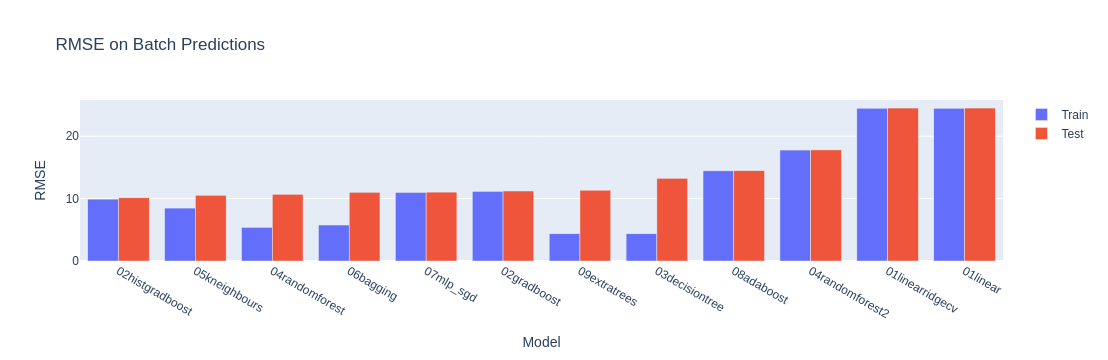

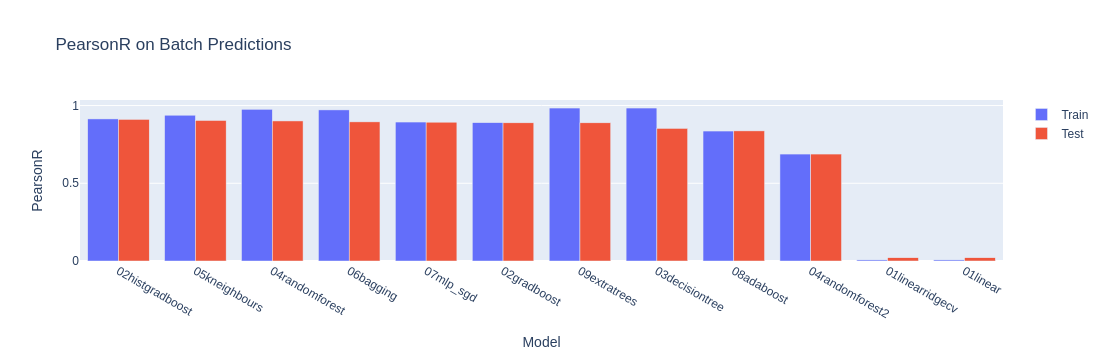

In [5]:
"""
-Below are performance metrics for batch predictions on Train vs Test data, 80:20 split
"""

## RMSE on Batch Predictions
fig = go.Figure(data = [
    go.Bar(name = "Train", x = df["Model"], y = df["RMSE (train)"]),
    go.Bar(name = "Test", x = df["Model"], y = df["RMSE (test)"]),
    # go.Bar(name = "Sample", x = df["Model"], y = df["RMSE (sample)"]),
])
fig.update_layout(title = "RMSE on Batch Predictions")
fig.update_layout(yaxis_title = "RMSE")
fig.update_layout(xaxis_title = "Model")
fig.update_layout(barmode = "group")
fig.show()


## PearsonR on Batch Predictions
fig = go.Figure(data = [
    go.Bar(name = "Train", x = df["Model"], y = df["PearsonR (train)"]),
    go.Bar(name = "Test", x = df["Model"], y = df["PearsonR (test)"]),
    # go.Bar(name = "Sample", x = df["Model"], y = df["PearsonR (sample)"]),
])
fig.update_layout(title = "PearsonR on Batch Predictions")
fig.update_layout(yaxis_title = "PearsonR")
fig.update_layout(xaxis_title = "Model")
fig.update_layout(barmode = "group")
fig.show()

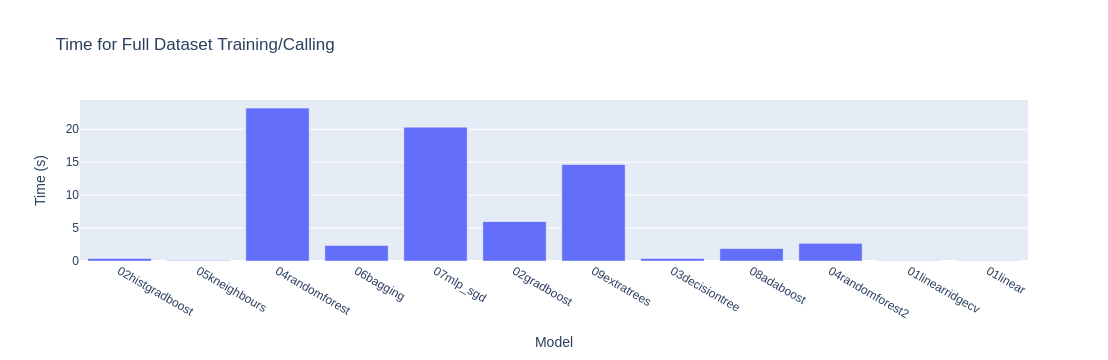

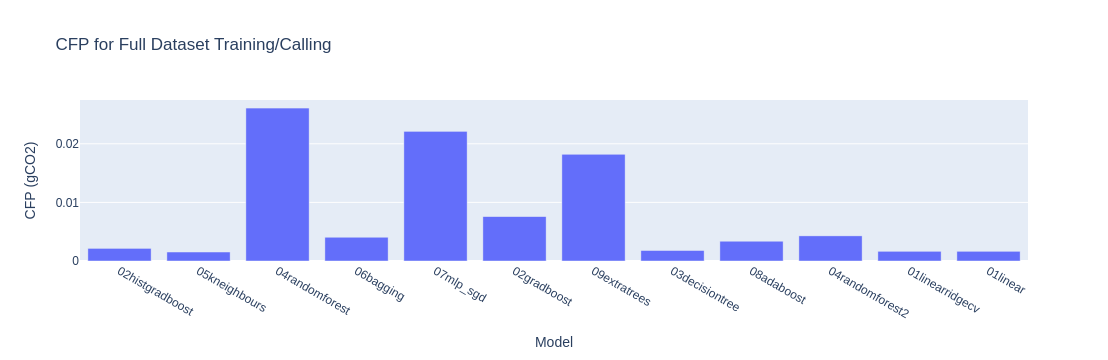

In [6]:
"""
-Below shows the Time and Carbon Footprint (calculated from Energy) for Training and for Batch Predictions
-Values for Train/Test datasets are scaled to the full number of data points, for a basic comparison

-Training typically uses more time than calling, on the same data set
-More training time means more carbon footprint
-In this Notebook, results are sorted by RMSE (test data). We see that performance does not always correlate with time/energy spent
"""

## Time for Training vs Batch Predictions
fig = go.Figure(data = [
    go.Bar(name = "Training", x = df["Model"], y = df["Training Time (s)"]),
    # go.Bar(name = "Train data", x = df["Model"], y = df["Calling Time (train) (s)"]),
    # go.Bar(name = "Test data", x = df["Model"], y = df["Calling Time (test) (s)"]),
])

fig.update_layout(title = "Time for Full Dataset Training/Calling")
fig.update_layout(yaxis_title = "Time (s)")
fig.update_layout(xaxis_title = "Model")
fig.update_layout(barmode = "group")
fig.show()

## CFP for Training vs Batch Predictions
fig = go.Figure(data = [
    go.Bar(name = "Training", x = df["Model"], y = df["Training CFP (gCO2)"]),
    # go.Bar(name = "Train data", x = df["Model"], y = df["Calling CFP (train) (gCO2)"]),
    # go.Bar(name = "Test data", x = df["Model"], y = df["Calling CFP (test) (gCO2)"]),
])
fig.update_layout(title = "CFP for Full Dataset Training/Calling")
fig.update_layout(yaxis_title = "CFP (gCO2)")
fig.update_layout(xaxis_title = "Model")
fig.update_layout(barmode = "group")
fig.show()

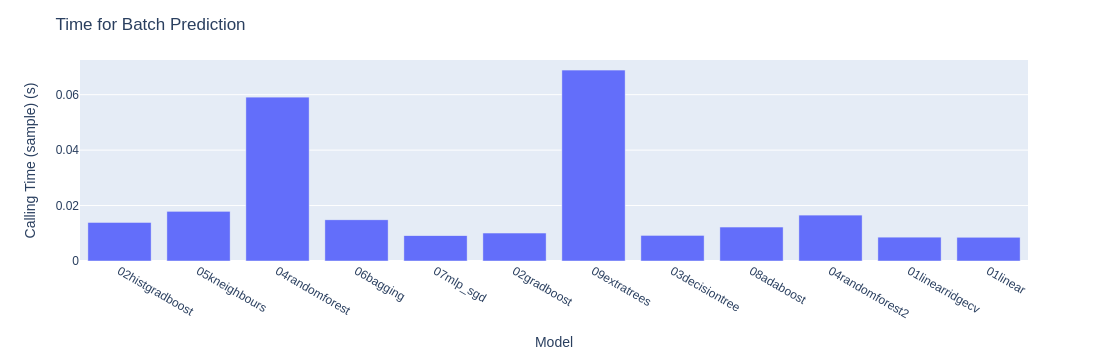

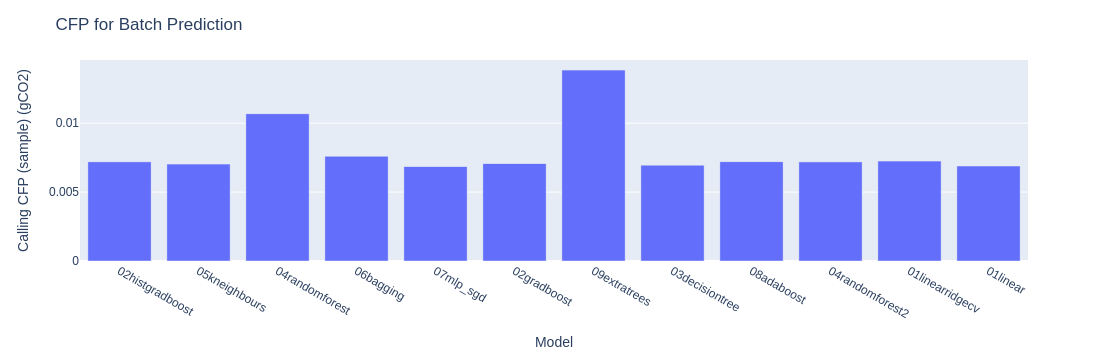

In [7]:
"""
-On a sample with 1000 samples from the dataset
-Calling different models has similar performance on batch prediction of this size
"""

## Time for Batch Prediction
fig = px.bar(df, x = "Model", y = "Calling Time (sample) (s)")
fig.update_layout(title = "Time for Batch Prediction")
fig.show()

## CFP for Batch Prediction
fig = px.bar(df, x = "Model", y = "Calling CFP (sample) (gCO2)")
fig.update_layout(title = "CFP for Batch Prediction")
fig.show()